# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

---

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

---
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [ ]:
NAME(s) = ""

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

   **Collapsed or damaged buildings are the main cause of earthquake deaths and economic loss, costing the U.S. about $14.7 billion a year. Quickly predicting how much each building deformed lets officials decide which buildings are unsafe and where to send rescue teams and inspectors first. This matters most in large cities, where there are too many buildings to inspect by hand and many lack detailed design records.**

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).



**The dataset has over 12,000 real recordings from 147 buildings during about 3,000 earthquakes, and it includes different kinds of buildings like steel, concrete, and masonry. Each recording comes with 41 features about the building and the shaking, so a model has plenty of information to pick up on patterns that a basic linear regression would miss. Physics-based models can be accurate, but they're slow and need detailed info about every building, which just isn't realistic right after an earthquake.**

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

Support Vector Regression (SVR) extends the Support Vector Machine from classification to the prediction of continuous values. A classification SVM finds the hyperplane that separates two classes with the largest possible margin. SVR instead fits a function to the data and surrounds it with a tube of half-width ε. Predictions that fall within the tube are considered acceptable and incur no loss, while predictions outside the tube are penalized in proportion to how far they fall beyond it. Among all functions that fit the data within this tolerance, SVR selects the flattest one, meaning the one with the smallest weight vector. This mirrors the margin-maximization principle of SVM and helps the model generalize rather than overfit. SVR also relies on the kernel trick to model nonlinear relationships, and its final prediction depends only on a subset of training points, the support vectors, which lie on or outside the boundary of the tube.



(1) This is the prediction function, f(x) = wᵀφ(x) + b, along with the condition that each prediction should be within ε of the true value. It's the same form as the SVM decision function. The difference is that in SVM we only care about its sign, while in SVR we use the actual value as the prediction.

(2) This is the goal: minimize ½‖w‖² plus a penalty for errors. The ½‖w‖² part keeps the function flat, which is the regression version of maximizing the margin in SVM. The penalty parameter controls the tradeoff between keeping the model simple and fitting the data closely.

(3) This defines the ε-insensitive loss. If a prediction is within ε of the true value, the loss is zero. If it's outside, the loss is how far past ε it went. This plays the same role as the hinge loss in SVM, which is zero for points safely on the correct side of the margin.

(4) Since some points will always fall outside the tube, slack variables ξ and ξ* are added. ξ measures how far a point is above the tube and ξ* how far below it. The objective becomes ½‖w‖² + C·Σ(ξ + ξ*). This is just like a soft-margin SVM, except SVR needs two slacks per point because a prediction can miss in either direction.

(5) These are the constraints: each point must be inside the tube or pay for the distance it falls outside, and the slacks can't be negative. In SVM, the matching constraint says each point must be on the correct side of the margin or pay a slack penalty.

(6) This is the Lagrangian. Each constraint gets folded into the objective with a Lagrange multiplier so we can solve the problem by taking derivatives. We did the same thing for SVM in class. SVR just has two multipliers per point (α and α*), one for each side of the tube.

(7) Setting the derivative with respect to w to zero shows that w is a weighted sum of the training points: w = Σ(α − α*)φ(x). In SVM, we got w = Σαyφ(x). Here (α − α*) takes the place of αy, and its sign tells us whether a point pulls the function up or down.

(8) Setting the derivative with respect to b to zero gives Σ(α − α*) = 0, meaning the upward and downward pulls balance out. In SVM, the matching condition is Σαy = 0.

(9) The derivatives with respect to the slack variables limit each multiplier to between 0 and C. This is the same "box constraint" as in soft-margin SVM, and it prevents any single outlier from having too much influence.

(10) Plugging w back into the function means the data only appears through dot products, which we can replace with a kernel. The paper uses the Gaussian (RBF) kernel, which measures how similar two points are. This is the same kernel trick from SVM, and it's why the paper tunes C and γ.

(11) This is the final prediction: f(x) = Σ(α − α*)K(xᵢ, x) + b. The prediction for a new building is a weighted combination of how similar it is to the training examples. Points inside the tube have α = α* = 0, so they drop out, and only the support vectors matter, exactly like in SVM.



## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [11]:
import pandas as pd

df = pd.read_excel("data_lab02 (2).xlsx", header=1)

features = [
    'B_Lat.', 'B_Long.', 'Height', 'No. of story', 'F1', 'F2',

    'SA1', 'SV1', 'SD1', 'SA2', 'SV2', 'SD2',
    'Avg_Sa', 'Avg_Sv', 'Avg_Sd',

    'Effective',
    'Bracketed 1 [0.05g]', 'Uniform [0.05g]',
    'Bracketed [0.1g]', 'Uniform [0.1g]',
    'Bracketed [0.15g]', 'Uniform [0.15g]',
    'Bracketed [0.2g]', 'Uniform [0.2g]',
    'Significant_a1 [(5-75)%]', 'Significant_a2 [(5-95)%]',
    'Significant_v1 [(5-75)%]', 'Significant_v2 [(5-95)%]',
    'Significant_d1 [(5-75)%]', 'Significant_d2 [(5-95)%]',
    'ZX',

    'E_Lat.', 'E_Long.', 'Magnitude', 'Epicentral distance (R)',
    'PGA', 'PGV', 'PGD', 'AI', 'CAV', 'DP'
]

data = df[features + ['Drift']].copy()

data.head()

,B_Lat.,B_Long.,Height,No. of story,F1,F2,SA1,SV1,SD1,SA2,...,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,PGD,AI,CAV,DP,Drift
0,[degree],[degree],[cm],Unnamed: 7_level_2,Hz,Hz,[cm/s2],[cm/s],[cm],[cm/s2],...,[degree],[Mw],[km],[cm/s2],[cm/s],[cm],[cm/s],[cm/s],[cm*s],[cm/cm]
1,36.132,140.073,3400,8,1.962438,1.596588,2.800003,0.245024,0.018094,2.064495,...,136.2283,5.3,420.7,1.577005,0.073452,0.009969,0.007308,14.943664,0.000081,-0.218343
2,36.132,140.073,3400,8,1.834042,1.684939,2.581543,0.259164,0.019248,2.205341,...,139.8917,3.8,16.6,3.449968,0.132411,0.013505,0.009687,10.468711,0.00005,-0.226958
3,36.132,140.073,3400,8,1.84608,1.696926,0.710809,0.083139,0.005131,0.671577,...,141.0583,4.2,132.2,0.854165,0.036735,0.00358,0.001478,4.989075,0.00001,-0.240754
4,36.132,140.073,3400,8,1.949488,1.580632,0.57816,0.053573,0.003708,0.366055,...,140.0867,3.4,9.8,0.549761,0.026009,0.002277,0.000338,2.158138,0.000001,-0.244348


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

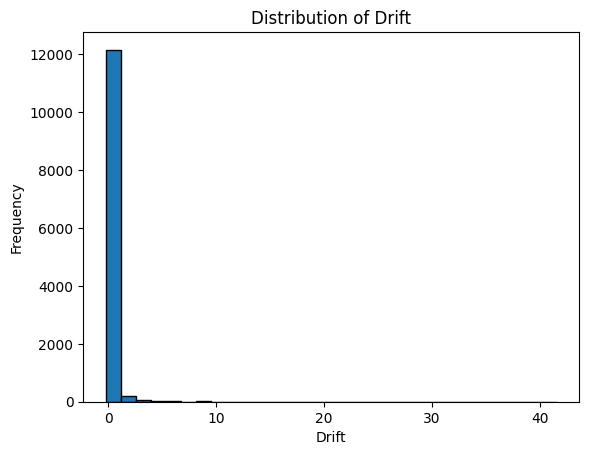

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

data = data.apply(pd.to_numeric, errors='coerce')

plt.hist(data['Drift'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Drift')
plt.ylabel('Frequency')
plt.title('Distribution of Drift')
plt.show()

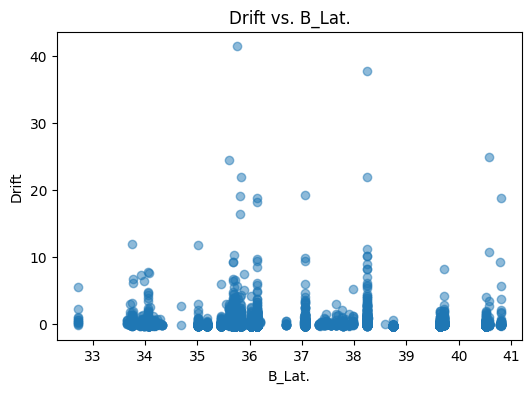

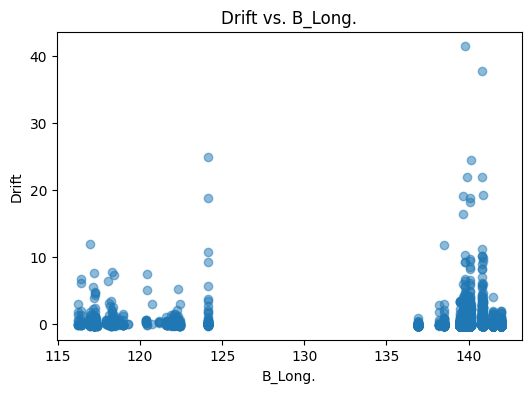

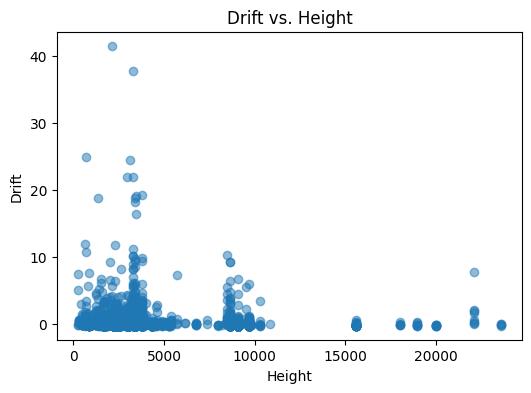

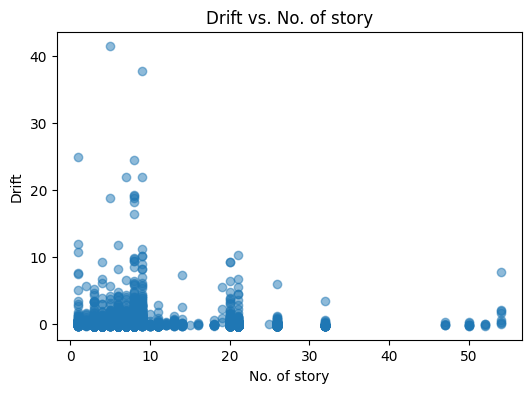

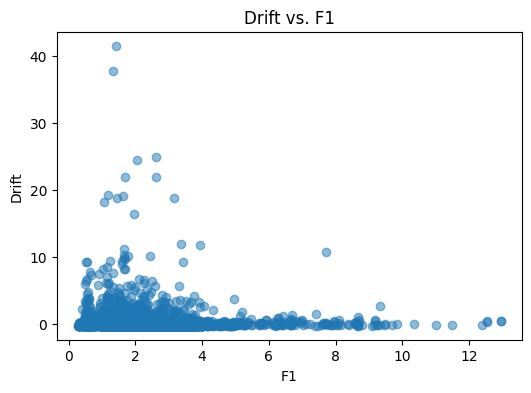

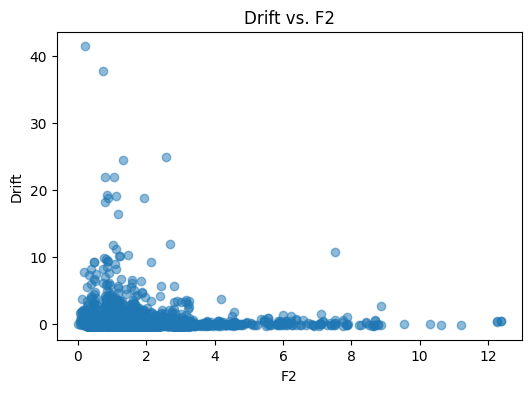

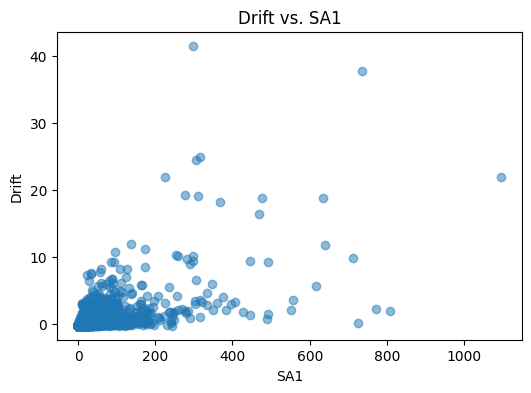

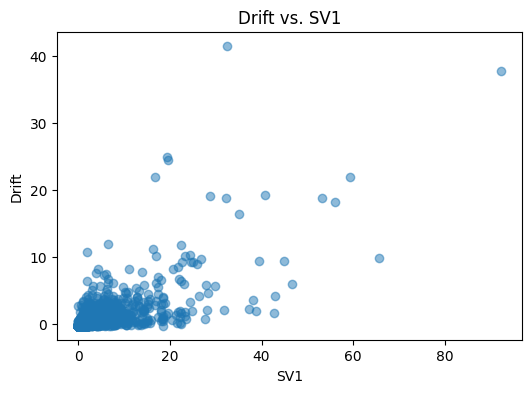

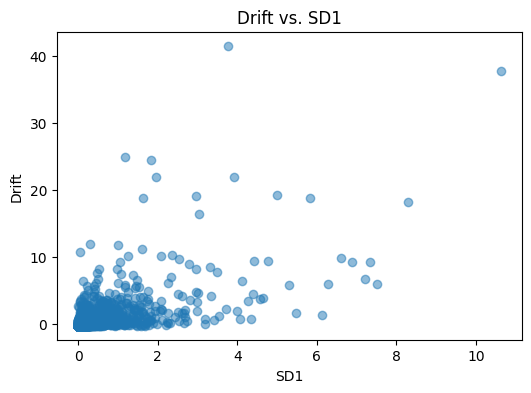

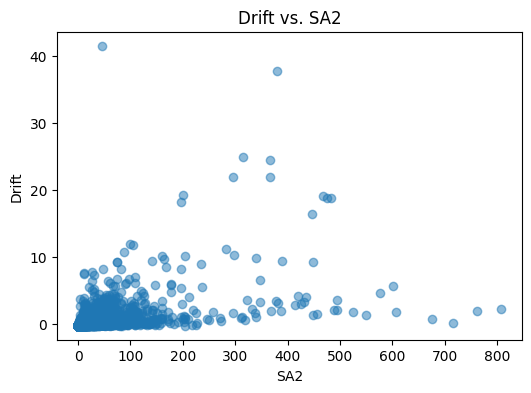

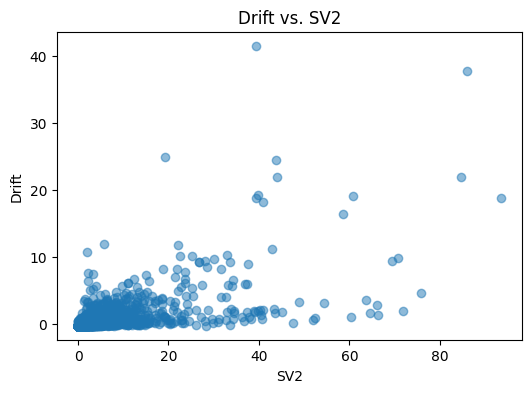

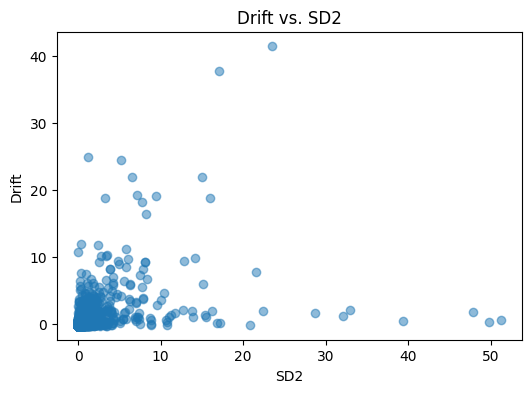

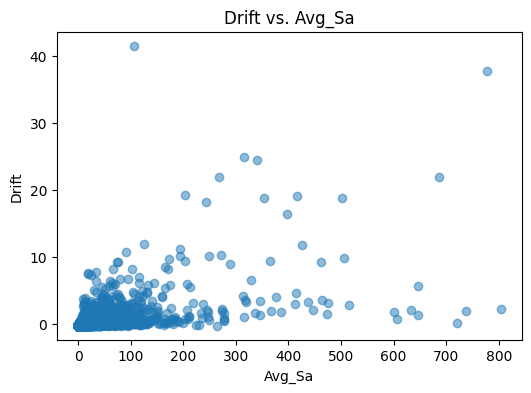

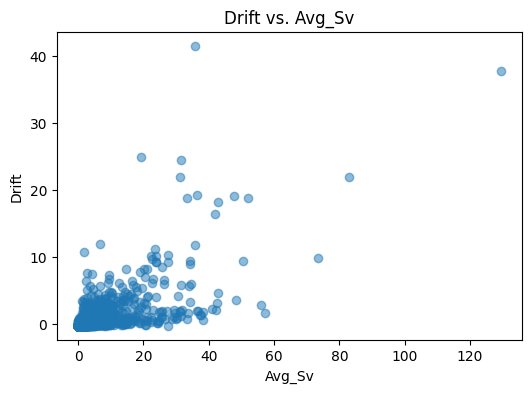

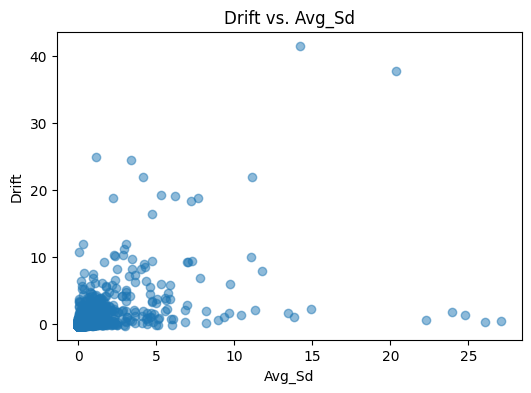

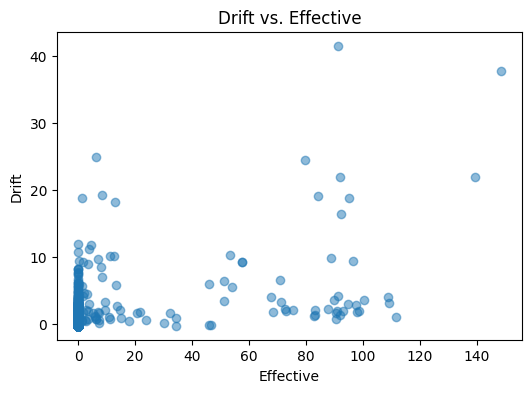

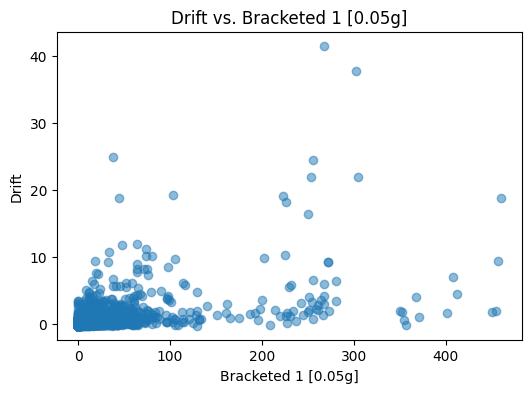

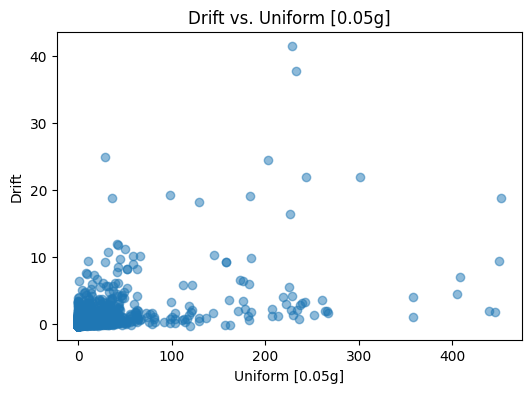

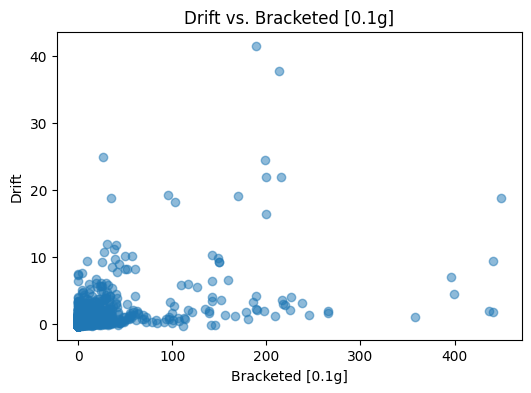

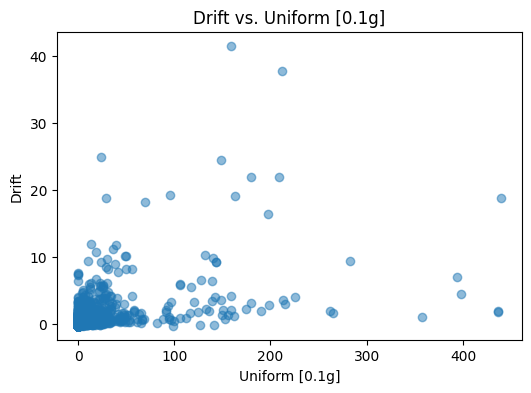

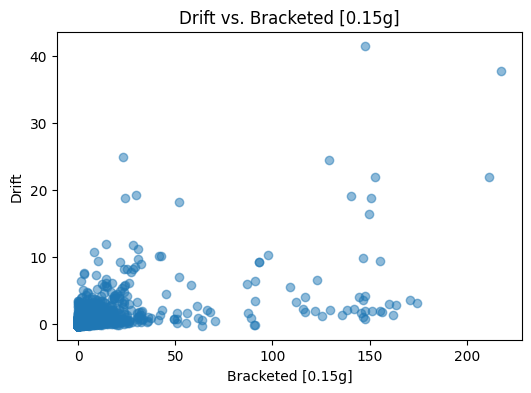

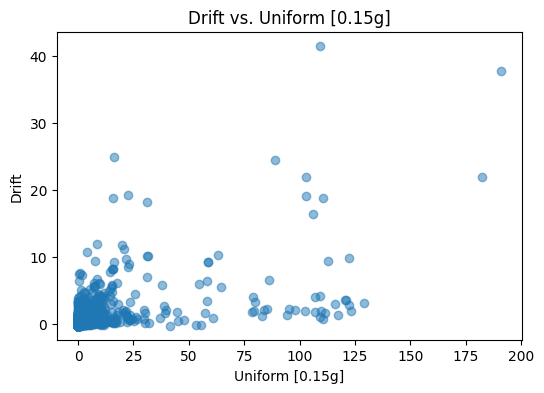

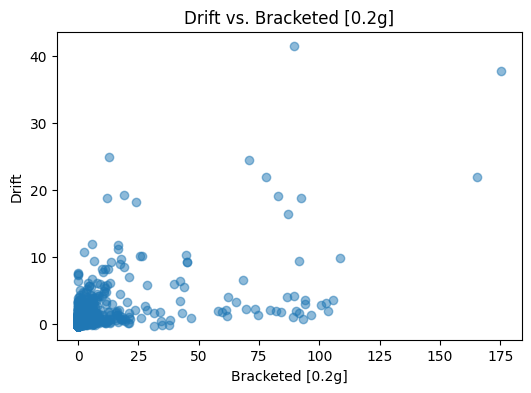

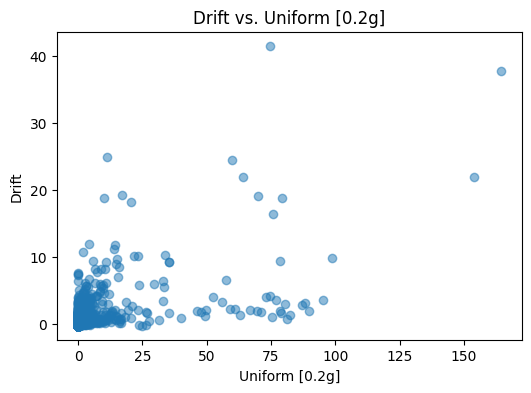

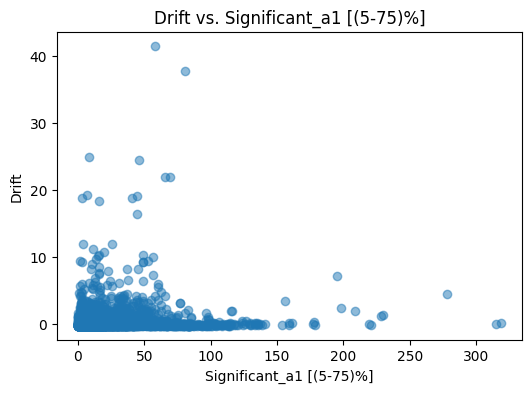

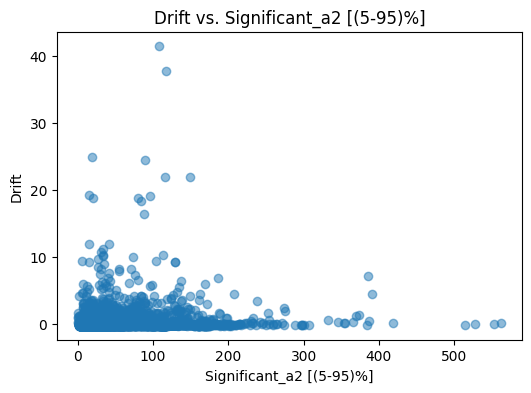

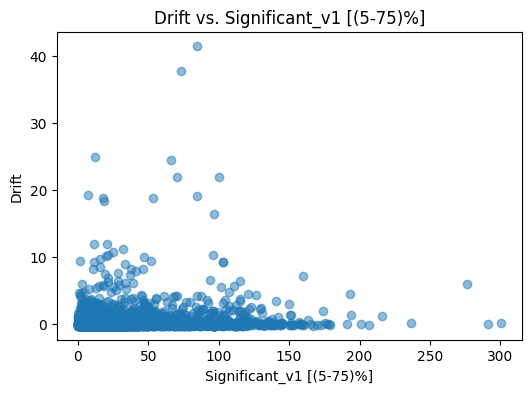

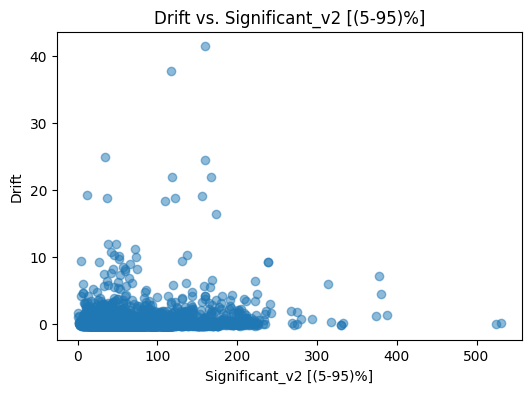

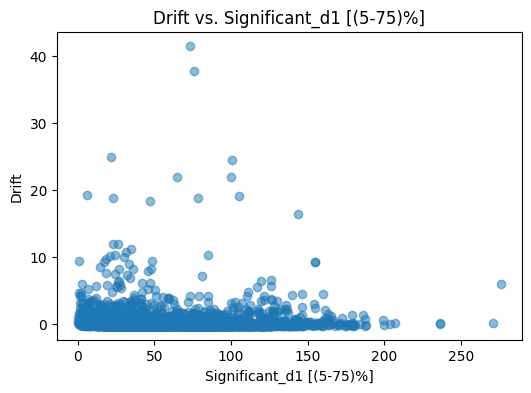

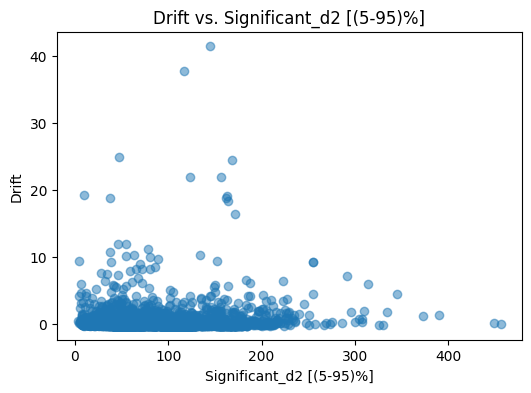

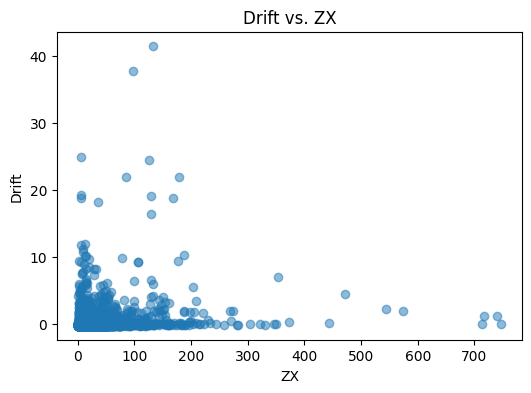

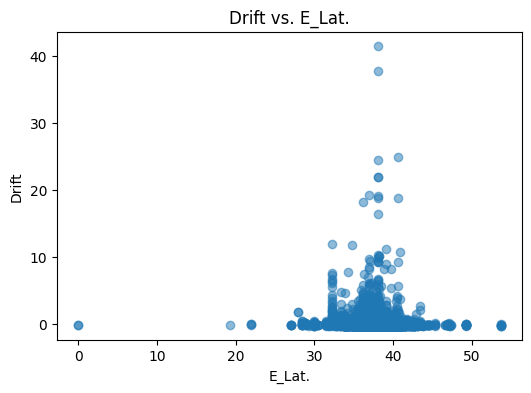

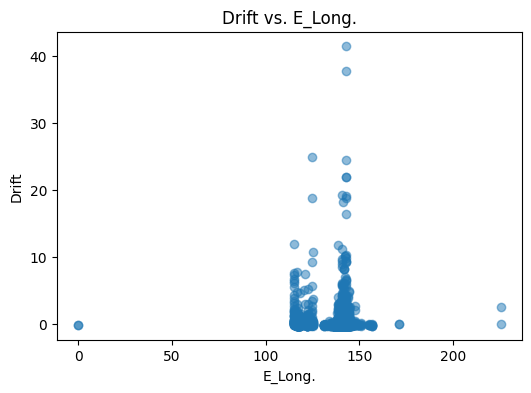

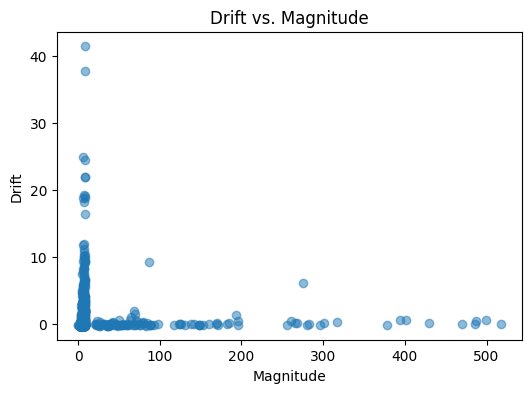

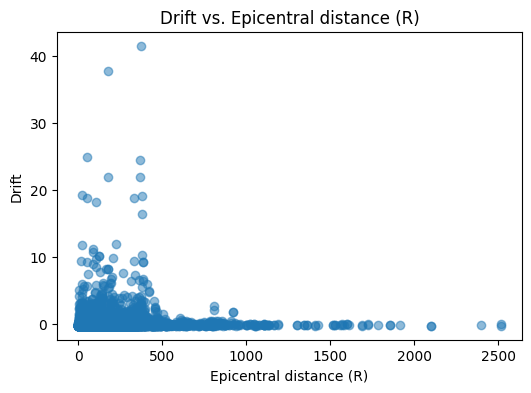

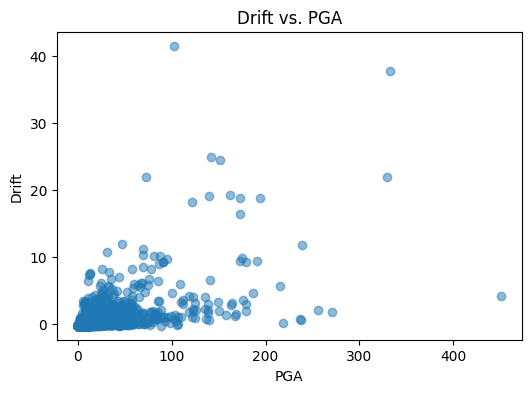

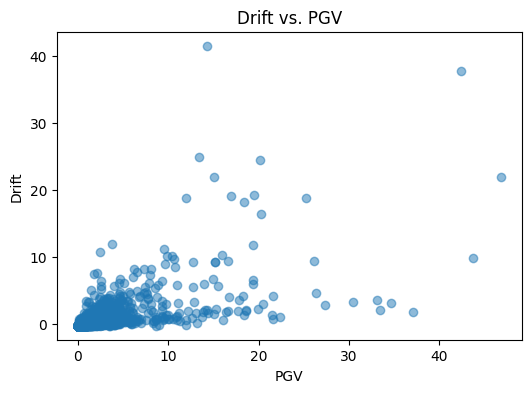

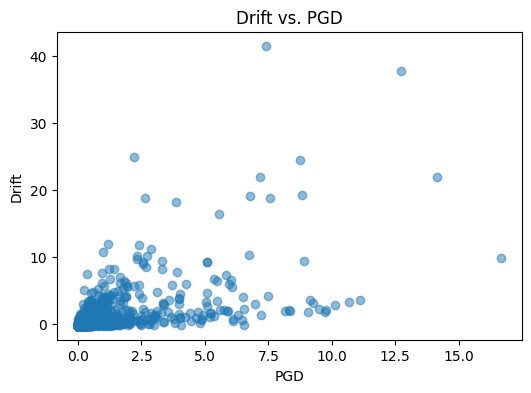

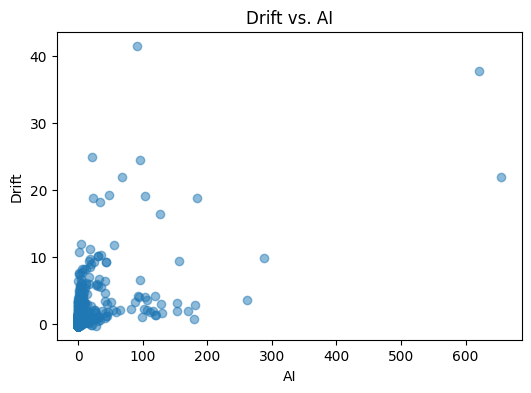

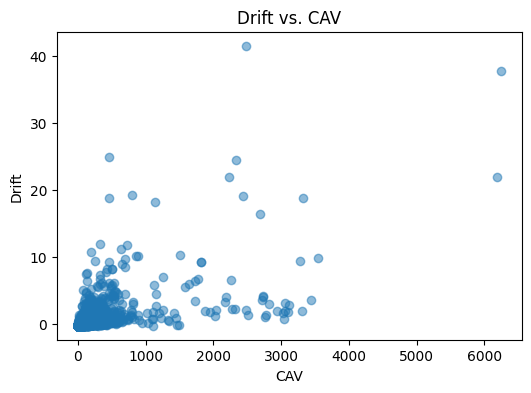

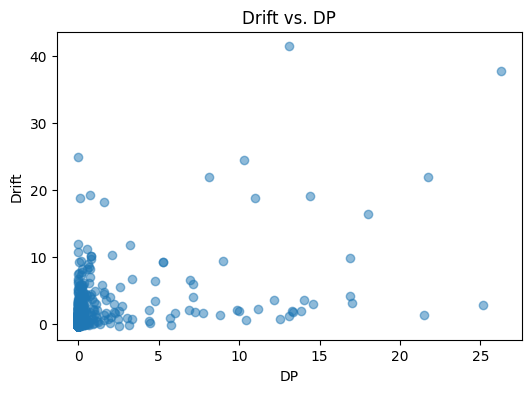

In [14]:
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(data[feature], data['Drift'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Drift')
    plt.title(f'Drift vs. {feature}')
    plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

The histogram shows that Drift is heavily right-skewed, with most recordings having very small drift and only a few having large values. In the scatter plots, velocity- and displacement-based features like PGV, PGD, SV1, SD1, and Avg_Sd show the clearest positive relationship with drift, and building frequency (F1, F2) also seems important, since lower-frequency buildings tend to drift more. Location features like latitude and longitude don't show a clear pattern, so they're likely less influential.

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [ ]:
# [Your code here]

b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [ ]:
# [Your code here]

c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

In [ ]:
# [Your code here]

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [ ]:
# [Your code here]

Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [ ]:
# [Your code here]

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [ ]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE